<a href="https://colab.research.google.com/github/dhanalakshmi-2007-6666/Customer-Segmentation--Unsupervised-Learning-/blob/main/Customer_centroidbased.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

In [ ]:
uploaded=files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
import pandas as pd
df=pd.read_csv("Mall_Customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


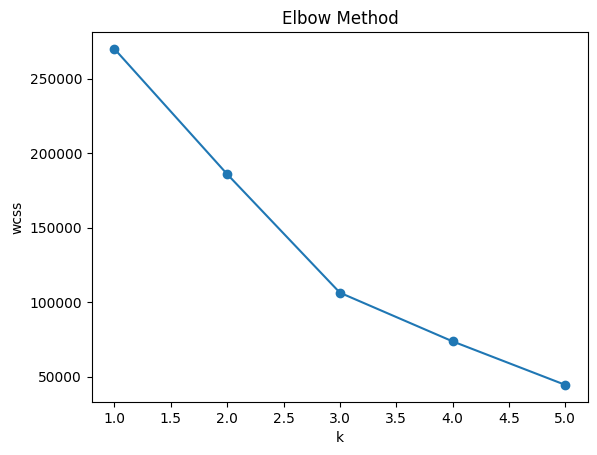

[269981.28000000014, 185917.1425392853, 106348.37306211119, 73679.78903948837, 44448.45544793369]


In [ ]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
x=df[['Annual Income (k$)','Spending Score (1-100)']].values
wcss=[]
for k in range(1,6):
    kmeans=KMeans(n_clusters=k,random_state=0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,6),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("wcss")
plt.show()
print(wcss)

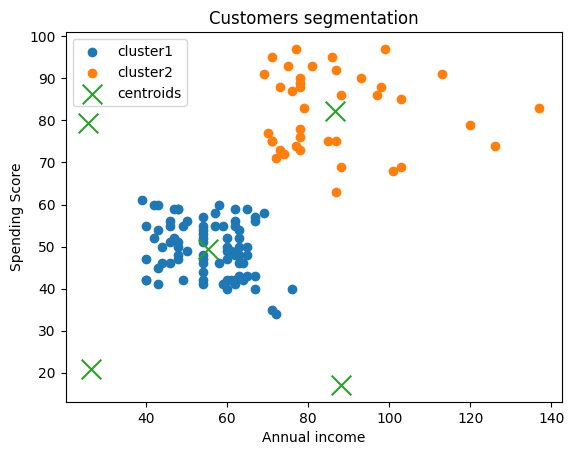

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=0)
y_kmeans=kmeans.fit_predict(x)
plt.scatter(x[y_kmeans==0,0],x[y_kmeans==0,1],label='cluster1')
plt.scatter(x[y_kmeans==1,0],x[y_kmeans==1,1],label='cluster2')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=200,marker='x',label='centroids')
plt.xlabel("Annual income")
plt.ylabel("Spending Score")
plt.title("Customers segmentation")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x, y_kmeans)
print(score)

0.553931997444648
